In [8]:
import os
import sys
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from datetime import datetime
from typing import Dict, List, Optional, Tuple, Iterable, Any
from dataclasses import dataclass
import re
import torch
import pickle
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
import json
# Add project root
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))


from src.data_loader.wind_turbine.turbine_data_loader import get_turbine_data_loader
from src.models.wind_turbine.anomaly_transformer.model.AnomalyTransformer import AnomalyTransformer

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print(f"Project root: {project_root}")
print("Libraries imported successfully.")

Project root: /home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel
Libraries imported successfully.


In [2]:
# PROCESSED_DIR = project_root / "data" / "processed" / "ieee_phm"
DATA_DIR = project_root / "data" / "raw" / "wind_turbine"
DATA_DIR_TRAIN = DATA_DIR / "train"
DATA_DIR_TEST = DATA_DIR / "test"

OUTPUT_DIR = project_root / "outputs" / "wind_turbine"
SAVE_MODEL_DIR = OUTPUT_DIR / "saved_models"

# print(f"Processed data directory: {PROCESSED_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Model save directory: {SAVE_MODEL_DIR}")

Output directory: /home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel/outputs/wind_turbine
Model save directory: /home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel/outputs/wind_turbine/saved_models


In [11]:
# Configuration
WIN_SIZE = 144
STEP = 144
BATCH_SIZE = 64
INPUT_C = 82
OUTPUT_C = 82
E_LAYERS = 3
TEMPERATURE = 50
ANORMLY_RATIO = 1.5

# Model class mapping
MODEL_CLASSES = {
    '0': 'Generator Bearing',
    '1': 'Gearbox',
    '2': 'Transformer',
    '3': 'Hydraulic'
}

# Threshold map (from solver.py)
THRESH_MAP = {
    '0': 0.00013377491304709106,
    '1': 0.00044517662157886675,
    '2': 0.00014006024604896057,
    '3': 7.12080005177995e-05
}

DATASET_NAME = "Wind Farm A"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cpu


In [12]:
def my_kl_loss(p, q):
    res = p * (torch.log(p + 0.0001) - torch.log(q + 0.0001))
    return torch.mean(torch.sum(res, dim=-1), dim=1)

In [13]:
# filepath: /home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel/notebooks/wind_turbine/01_load_data_and_models.ipynb
import joblib

# ===== SELECT WHICH MODEL CLASS TO ANALYZE =====
MODEL_ = '0'  # Change to '0', '1', '2', or '3'

print(f"Loading model class: {MODEL_} ({MODEL_CLASSES[MODEL_]})")

model_name = DATASET_NAME + MODEL_

# Paths
scaler_path = OUTPUT_DIR / f"model_{MODEL_}" / "scaler.joblib"
checkpoint_path = SAVE_MODEL_DIR / f"{DATASET_NAME}{MODEL_}_checkpoint1_.pth"

# Load scaler
scaler = joblib.load(scaler_path)
print(f"Scaler loaded from {scaler_path}")

# Load test data
test_loader, features, _, _ = get_turbine_data_loader(
    str(DATA_DIR_TEST), model_name,
    batch_size=BATCH_SIZE, win_size=WIN_SIZE, step=STEP,
    mode='test', scaler=scaler
)

# Load train data (for threshold calibration reference)
train_loader, _, _, background_data = get_turbine_data_loader(
    str(DATA_DIR_TRAIN), model_name,
    batch_size=BATCH_SIZE, win_size=WIN_SIZE, step=STEP,
    mode='train', scaler=scaler
)

# Load validation data
vali_loader, _, _, _ = get_turbine_data_loader(
    str(DATA_DIR_TRAIN), model_name,
    batch_size=BATCH_SIZE, win_size=WIN_SIZE, step=STEP,
    mode='val', scaler=scaler
)

print(f"\nNumber of features: {len(features)}")
print(f"Features: {features[:10]}... (showing first 10)")

Loading model class: 0 (Generator Bearing)
Scaler loaded from /home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel/outputs/wind_turbine/model_0/scaler.joblib
test: torch.Size([7777, 82])


/home/rdb/Documents/nirban_documents/python_programs/.venv/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


train: torch.Size([46800, 82])
val: torch.Size([5328, 82])

Number of features: 82
Features: ['status_type_id', 'sensor_0_avg', 'sensor_1_avg', 'sensor_2_avg', 'wind_speed_3_avg', 'wind_speed_4_avg', 'wind_speed_3_max', 'wind_speed_3_min', 'wind_speed_3_std', 'sensor_5_avg']... (showing first 10)


In [14]:
# Build and load model
model = AnomalyTransformer(
    win_size=WIN_SIZE,
    enc_in=INPUT_C,
    c_out=OUTPUT_C,
    e_layers=E_LAYERS
)

model.load_state_dict(torch.load(checkpoint_path, map_location=device), strict=False)
model.to(device)
model.eval()

thresh = THRESH_MAP[MODEL_]
print(f"Model loaded from: {checkpoint_path}")
print(f"Threshold for class {MODEL_} ({MODEL_CLASSES[MODEL_]}): {thresh:.10f}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model loaded from: /home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel/outputs/wind_turbine/saved_models/Wind Farm A0_checkpoint1_.pth
Threshold for class 0 (Generator Bearing): 0.0001337749
Model parameters: 4,918,389


In [15]:
criterion = torch.nn.MSELoss(reduction='none')

all_scores = []        # per-timestep anomaly scores
all_timestamps = []    # per-timestep timestamps
all_true_labels = []   # per-window true labels
all_pred_labels = []   # per-window predicted labels
all_rec_losses = []    # per-timestep reconstruction loss
all_inputs = []        # raw inputs
all_outputs = []       # reconstructed outputs

with torch.no_grad():
    for i, (input_data, labels, date_time) in enumerate(test_loader):
        inp = input_data.float().to(device)
        output, series, prior, sigmas = model(inp)
        
        # Compute association discrepancy
        loss = torch.mean(criterion(inp, output), dim=-1)  # (B, L)
        
        series_loss = 0.0
        prior_loss = 0.0
        for u in range(len(prior)):
            if u == 0:
                series_loss = my_kl_loss(
                    series[u],
                    (prior[u] / torch.unsqueeze(torch.sum(prior[u], dim=-1), dim=-1).repeat(1, 1, 1, WIN_SIZE)).detach()
                ) * TEMPERATURE
                prior_loss = my_kl_loss(
                    (prior[u] / torch.unsqueeze(torch.sum(prior[u], dim=-1), dim=-1).repeat(1, 1, 1, WIN_SIZE)),
                    series[u].detach()
                ) * TEMPERATURE
            else:
                series_loss += my_kl_loss(
                    series[u],
                    (prior[u] / torch.unsqueeze(torch.sum(prior[u], dim=-1), dim=-1).repeat(1, 1, 1, WIN_SIZE)).detach()
                ) * TEMPERATURE
                prior_loss += my_kl_loss(
                    (prior[u] / torch.unsqueeze(torch.sum(prior[u], dim=-1), dim=-1).repeat(1, 1, 1, WIN_SIZE)),
                    series[u].detach()
                ) * TEMPERATURE
        
        metric = torch.softmax((-series_loss - prior_loss), dim=-1)  # (B, L)
        cri = (metric * loss).detach().cpu().numpy()  # (B, L)
        
        rec_loss = loss.detach().cpu().numpy()
        
        # Collect per-timestep data
        date_np = np.array(date_time)  # (B, L, 1) or (B, L)
        
        for b in range(cri.shape[0]):
            all_scores.append(cri[b])
            all_rec_losses.append(rec_loss[b])
            
            # Extract timestamps for this window
            ts = [date_np[b][t][0] if len(date_np[b][t].shape) == 0 or date_np[b][t].ndim == 0 
                  else date_np[b][t].item() if hasattr(date_np[b][t], 'item') 
                  else str(date_np[b][t][0]) for t in range(len(date_np[b]))]
            all_timestamps.append(ts)
            all_inputs.append(input_data[b].cpu().numpy())
            all_outputs.append(output[b].detach().cpu().numpy())
        
        # Window-level labels
        true_batch = labels.view(-1).cpu().numpy().astype(int).tolist()
        pred_batch = [
            int(np.sum(cri[b] > thresh) >= np.round(ANORMLY_RATIO * cri[b].shape[0] / 100))
            for b in range(cri.shape[0])
        ]
        
        all_true_labels.extend(true_batch)
        all_pred_labels.extend(pred_batch)

all_scores = np.array(all_scores)       # (N_windows, L)
all_rec_losses = np.array(all_rec_losses)
all_inputs = np.array(all_inputs)
all_outputs = np.array(all_outputs)

print(f"Total test windows: {len(all_scores)}")
print(f"Score array shape: {all_scores.shape}")
print(f"True anomalous windows: {sum(all_true_labels)}")
print(f"Predicted anomalous windows: {sum(all_pred_labels)}")

Total test windows: 54
Score array shape: (54, 144)
True anomalous windows: 47
Predicted anomalous windows: 50


  Generator Bearing Fault Detection Results
  Accuracy:  0.7963
  Precision: 0.8600
  Recall:    0.9149
  F1-Score:  0.8866


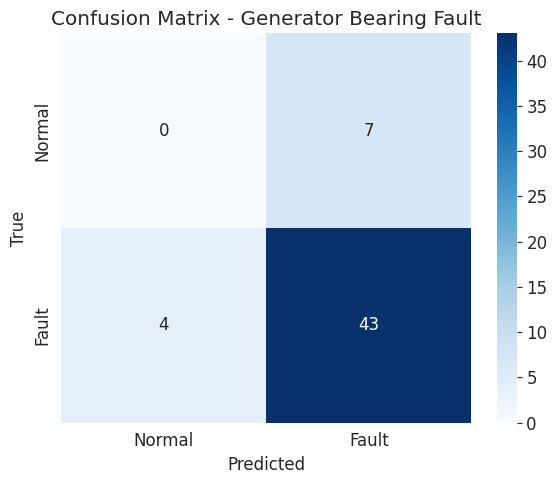

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

acc = accuracy_score(all_true_labels, all_pred_labels)
prec = precision_score(all_true_labels, all_pred_labels, zero_division=0)
rec = recall_score(all_true_labels, all_pred_labels, zero_division=0)
f1 = f1_score(all_true_labels, all_pred_labels, zero_division=0)

print(f"{'='*50}")
print(f"  {MODEL_CLASSES[MODEL_]} Fault Detection Results")
print(f"{'='*50}")
print(f"  Accuracy:  {acc:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall:    {rec:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"{'='*50}")

# Confusion matrix
cm = confusion_matrix(all_true_labels, all_pred_labels)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal', 'Fault'], yticklabels=['Normal', 'Fault'])
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix - {MODEL_CLASSES[MODEL_]} Fault')
plt.tight_layout()
plt.show()

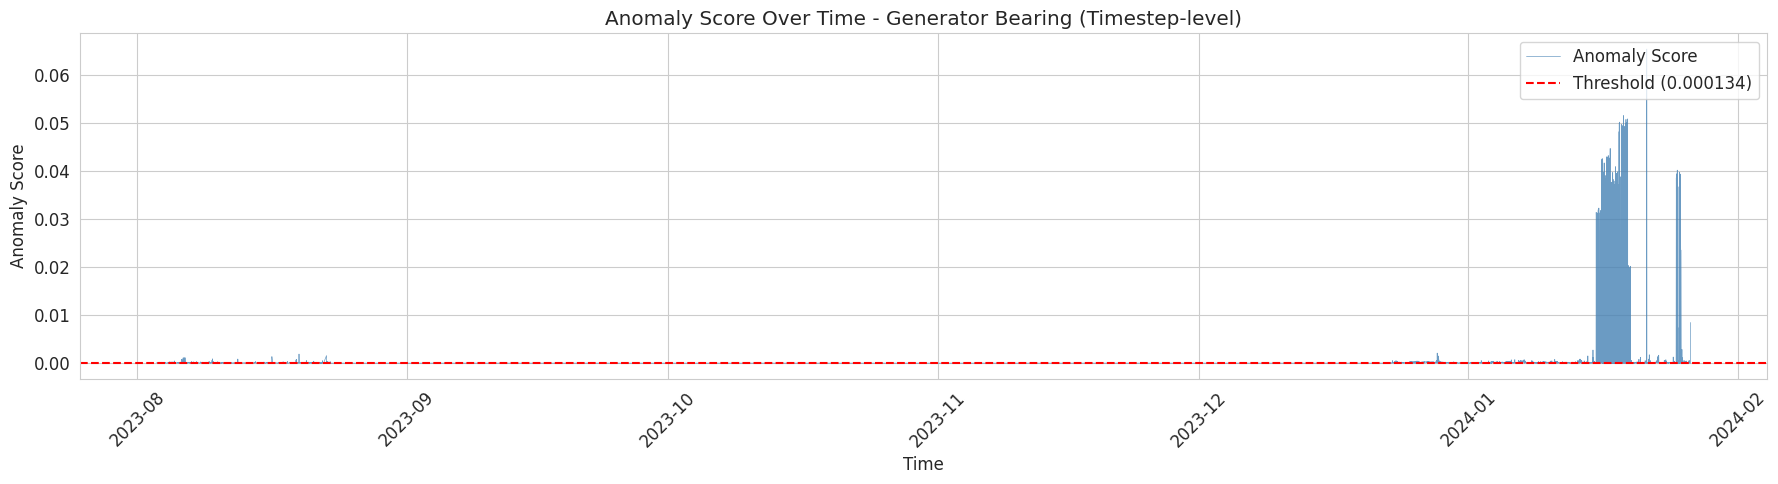

Total timesteps: 7776
Timesteps above threshold: 1960 (25.21%)


In [17]:
# Flatten scores and timestamps into a single time series
flat_scores = all_scores.reshape(-1)
flat_timestamps = []
for ts_window in all_timestamps:
    flat_timestamps.extend(ts_window)

# Convert timestamps to datetime
flat_timestamps_dt = pd.to_datetime(flat_timestamps)

# Create a DataFrame for easy plotting
df_scores = pd.DataFrame({
    'timestamp': flat_timestamps_dt,
    'anomaly_score': flat_scores
})
df_scores = df_scores.sort_values('timestamp').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(df_scores['timestamp'], df_scores['anomaly_score'], 
        linewidth=0.5, color='steelblue', alpha=0.8, label='Anomaly Score')
ax.axhline(y=thresh, color='red', linestyle='--', linewidth=1.5, label=f'Threshold ({thresh:.6f})')

ax.set_xlabel('Time')
ax.set_ylabel('Anomaly Score')
ax.set_title(f'Anomaly Score Over Time - {MODEL_CLASSES[MODEL_]} (Timestep-level)')
ax.legend(loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Total timesteps: {len(flat_scores)}")
print(f"Timesteps above threshold: {np.sum(flat_scores > thresh)} ({100*np.sum(flat_scores > thresh)/len(flat_scores):.2f}%)")

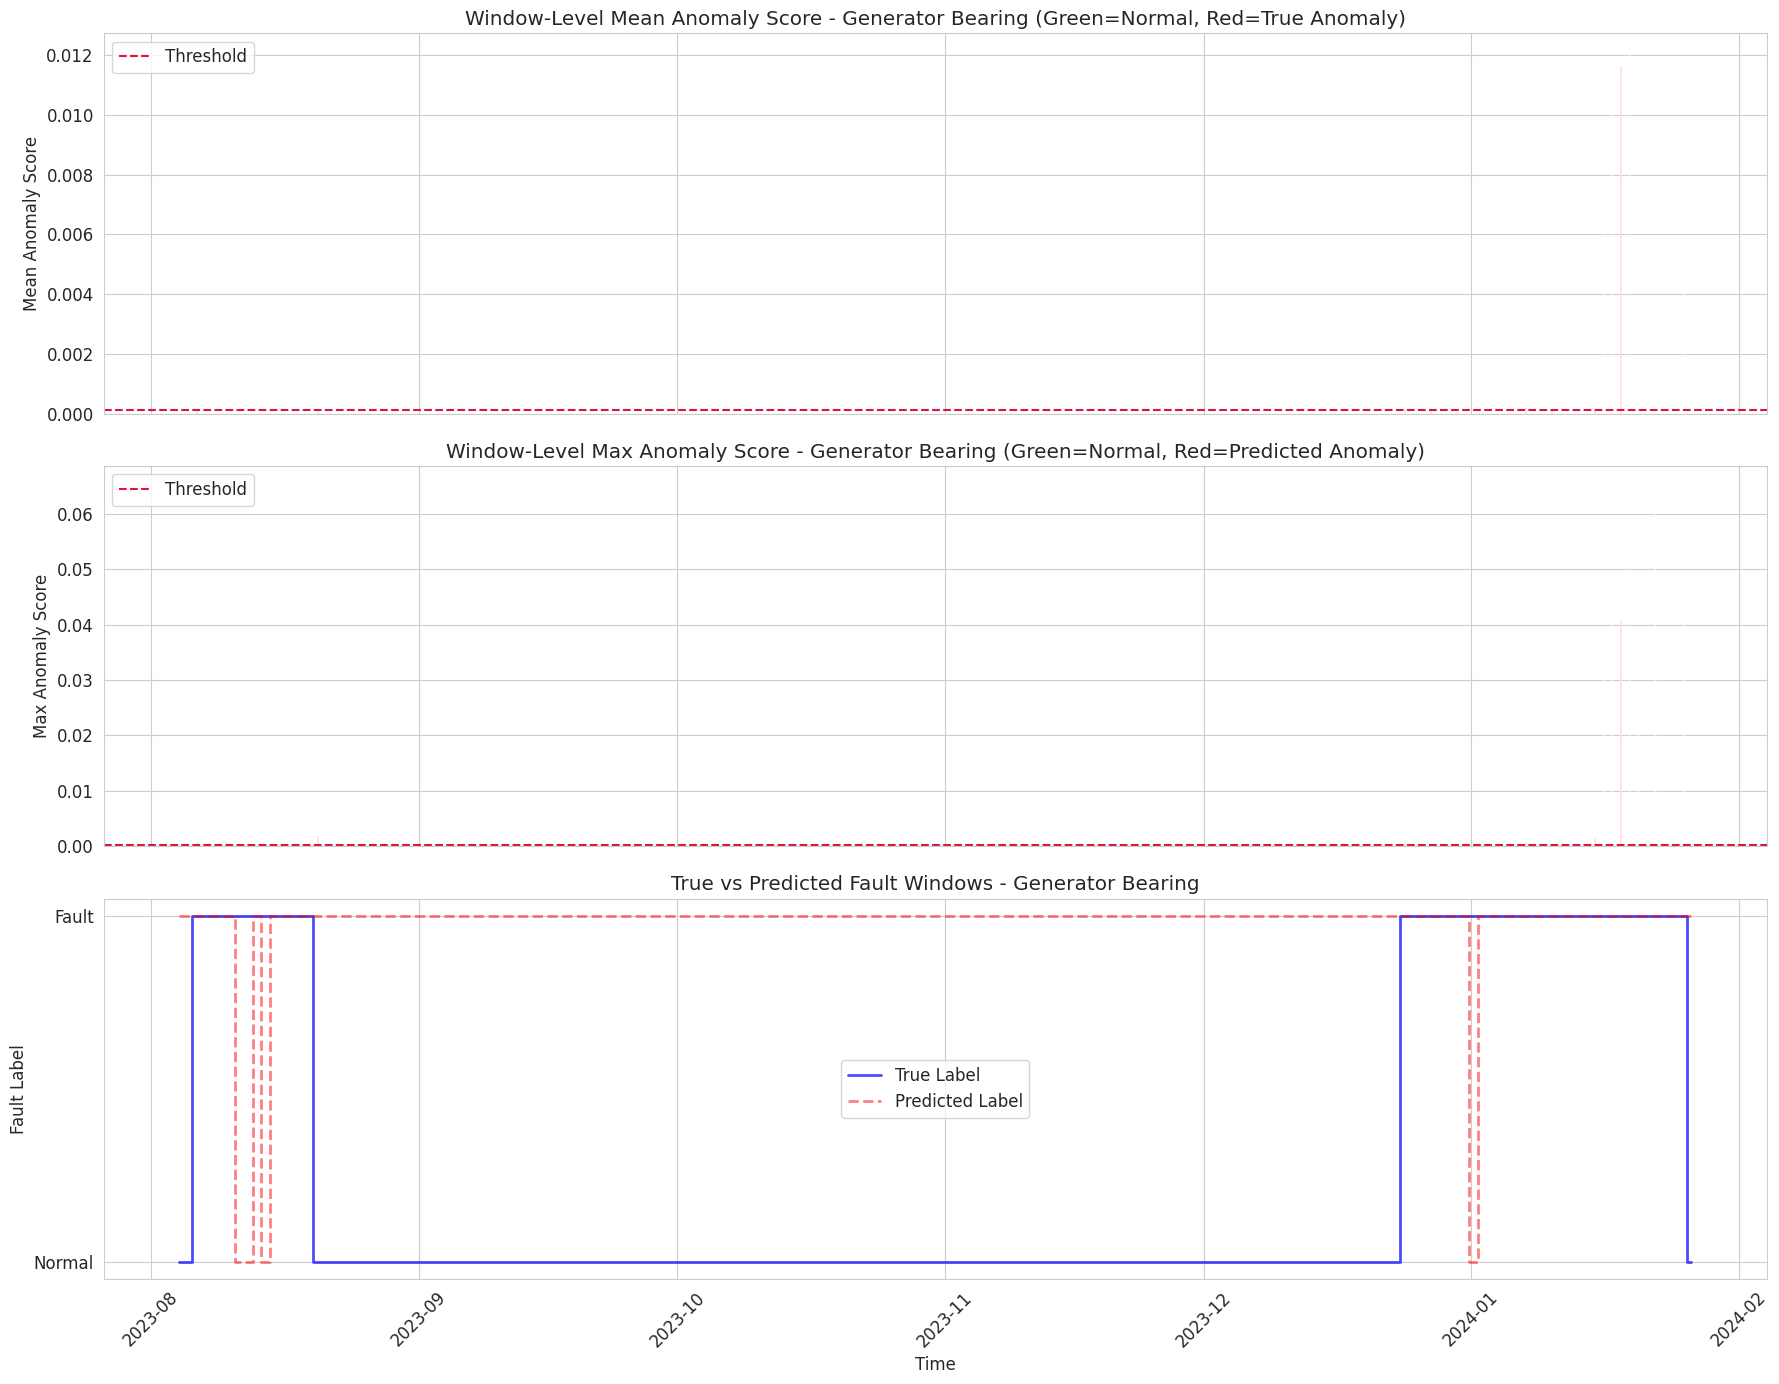

In [18]:
# Window-level mean anomaly score with true/predicted labels
window_mean_scores = all_scores.mean(axis=1)
window_max_scores = all_scores.max(axis=1)

# Get the last timestamp per window as the window timestamp
window_timestamps = [pd.to_datetime(ts[-1]) for ts in all_timestamps]

df_windows = pd.DataFrame({
    'timestamp': window_timestamps,
    'mean_score': window_mean_scores,
    'max_score': window_max_scores,
    'true_label': all_true_labels,
    'pred_label': all_pred_labels
})
df_windows = df_windows.sort_values('timestamp').reset_index(drop=True)

fig, axes = plt.subplots(3, 1, figsize=(18, 14), sharex=True)

# Plot 1: Mean anomaly score per window
ax1 = axes[0]
colors = ['green' if l == 0 else 'red' for l in df_windows['true_label']]
ax1.bar(df_windows['timestamp'], df_windows['mean_score'], color=colors, alpha=0.7, width=0.02)
ax1.axhline(y=thresh, color='crimson', linestyle='--', linewidth=1.5, label=f'Threshold')
ax1.set_ylabel('Mean Anomaly Score')
ax1.set_title(f'Window-Level Mean Anomaly Score - {MODEL_CLASSES[MODEL_]} (Green=Normal, Red=True Anomaly)')
ax1.legend()

# Plot 2: Max anomaly score per window
ax2 = axes[1]
colors_pred = ['green' if l == 0 else 'red' for l in df_windows['pred_label']]
ax2.bar(df_windows['timestamp'], df_windows['max_score'], color=colors_pred, alpha=0.7, width=0.02)
ax2.axhline(y=thresh, color='crimson', linestyle='--', linewidth=1.5, label=f'Threshold')
ax2.set_ylabel('Max Anomaly Score')
ax2.set_title(f'Window-Level Max Anomaly Score - {MODEL_CLASSES[MODEL_]} (Green=Normal, Red=Predicted Anomaly)')
ax2.legend()

# Plot 3: True vs Predicted labels
ax3 = axes[2]
ax3.step(df_windows['timestamp'], df_windows['true_label'], where='mid', 
         label='True Label', color='blue', linewidth=2, alpha=0.7)
ax3.step(df_windows['timestamp'], df_windows['pred_label'], where='mid', 
         label='Predicted Label', color='red', linewidth=2, alpha=0.5, linestyle='--')
ax3.set_ylabel('Fault Label')
ax3.set_xlabel('Time')
ax3.set_title(f'True vs Predicted Fault Windows - {MODEL_CLASSES[MODEL_]}')
ax3.legend()
ax3.set_yticks([0, 1])
ax3.set_yticklabels(['Normal', 'Fault'])

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

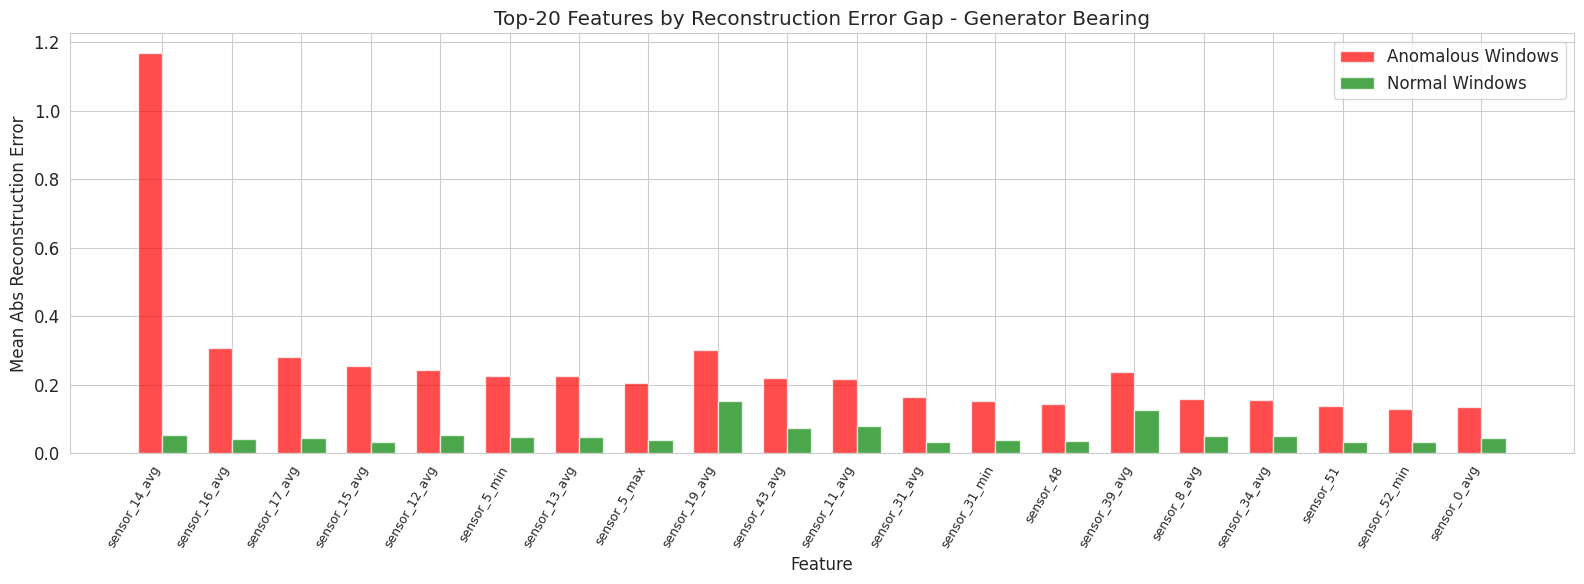

In [19]:
# Feature-level reconstruction error analysis for anomalous windows
anomalous_idxs = [i for i, l in enumerate(all_pred_labels) if l == 1]
normal_idxs = [i for i, l in enumerate(all_pred_labels) if l == 0]

if len(anomalous_idxs) > 0:
    # Mean absolute reconstruction error per feature
    feature_names = features[1:] if features[0].lower() in ['time_stamp', 'timestamp', 'id'] else features
    
    anom_inputs = all_inputs[anomalous_idxs]    # (N_anom, L, F)
    anom_outputs = all_outputs[anomalous_idxs]  # (N_anom, L, F)
    anom_rec_error = np.abs(anom_inputs - anom_outputs).mean(axis=(0, 1))  # (F,)
    
    if len(normal_idxs) > 0:
        norm_inputs = all_inputs[normal_idxs]
        norm_outputs = all_outputs[normal_idxs]
        norm_rec_error = np.abs(norm_inputs - norm_outputs).mean(axis=(0, 1))
    else:
        norm_rec_error = np.zeros_like(anom_rec_error)
    
    # Top-K features by reconstruction error difference
    K = 20
    error_diff = anom_rec_error - norm_rec_error
    top_k_idxs = np.argsort(error_diff)[-K:][::-1]
    
    fig, ax = plt.subplots(figsize=(16, 6))
    x = np.arange(K)
    width = 0.35
    
    top_feature_names = [feature_names[i] if i < len(feature_names) else f'F{i}' for i in top_k_idxs]
    
    ax.bar(x - width/2, anom_rec_error[top_k_idxs], width, label='Anomalous Windows', color='red', alpha=0.7)
    ax.bar(x + width/2, norm_rec_error[top_k_idxs], width, label='Normal Windows', color='green', alpha=0.7)
    
    ax.set_xlabel('Feature')
    ax.set_ylabel('Mean Abs Reconstruction Error')
    ax.set_title(f'Top-{K} Features by Reconstruction Error Gap - {MODEL_CLASSES[MODEL_]}')
    ax.set_xticks(x)
    ax.set_xticklabels(top_feature_names, rotation=60, ha='right', fontsize=9)
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No anomalous windows detected.")

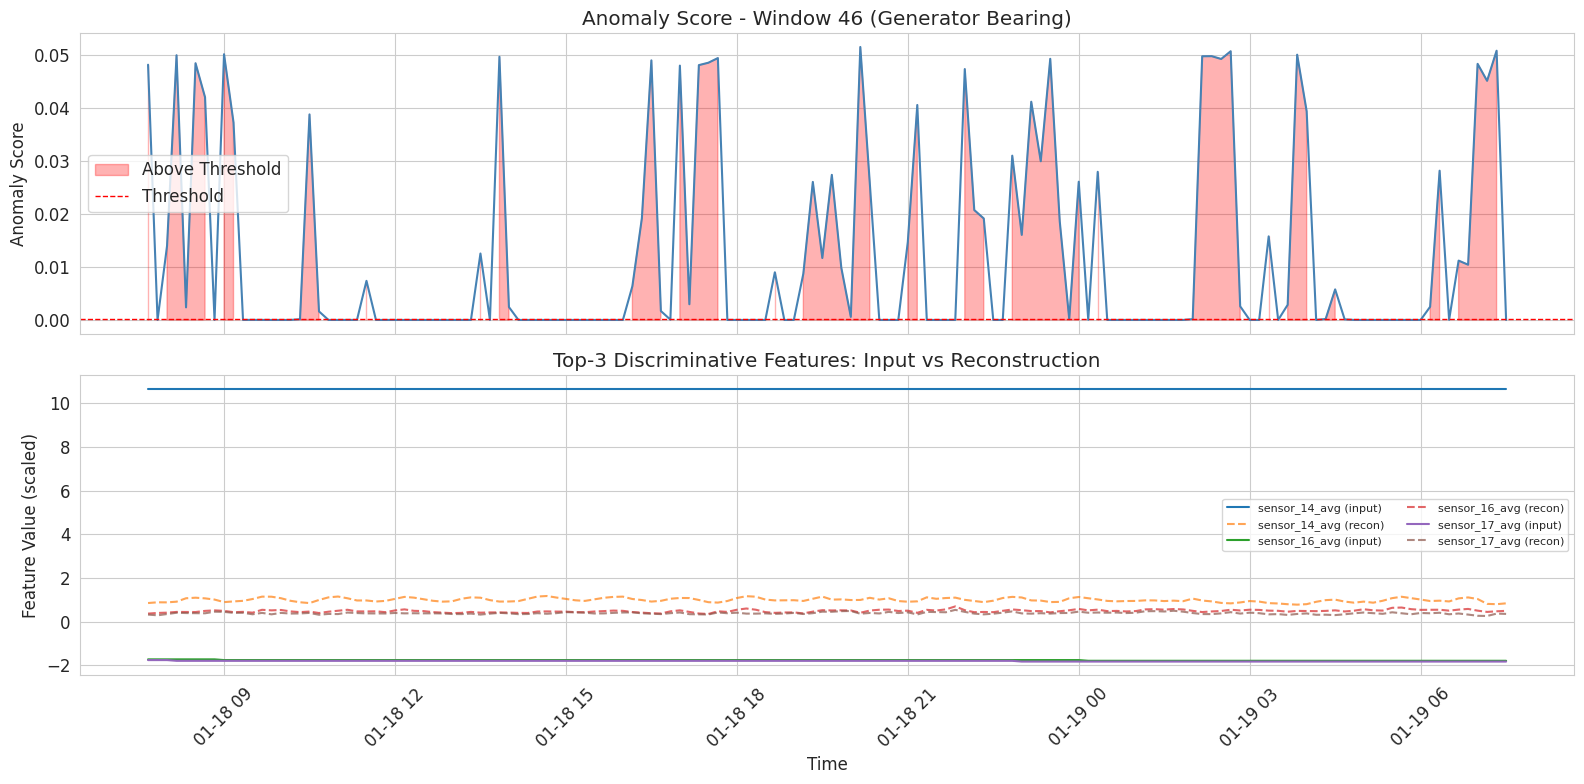

Selected window index: 46
Window timestamp range: 2024-01-18 07:40:00 → 2024-01-19 07:30:00
Mean anomaly score: 0.01212170
Max anomaly score: 0.05153971
Timesteps above threshold: 66/144


In [20]:
# Detailed view of a single anomalous window
if len(anomalous_idxs) > 0:
    # Pick the window with the highest mean anomaly score
    anom_mean_scores = window_mean_scores[anomalous_idxs]
    selected_local = np.argmax(anom_mean_scores)
    selected_global = anomalous_idxs[selected_local]
    
    window_score = all_scores[selected_global]
    window_ts = all_timestamps[selected_global]
    window_ts_dt = pd.to_datetime(window_ts)
    
    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
    
    # Plot anomaly score across the window
    ax1 = axes[0]
    ax1.plot(window_ts_dt, window_score, color='steelblue', linewidth=1.5)
    ax1.fill_between(window_ts_dt, 0, window_score, 
                     where=(window_score > thresh), color='red', alpha=0.3, label='Above Threshold')
    ax1.axhline(y=thresh, color='red', linestyle='--', linewidth=1, label='Threshold')
    ax1.set_ylabel('Anomaly Score')
    ax1.set_title(f'Anomaly Score - Window {selected_global} ({MODEL_CLASSES[MODEL_]})')
    ax1.legend()
    
    # Plot top-3 features: input vs reconstruction
    ax2 = axes[1]
    top3_idxs = np.argsort(error_diff)[-3:][::-1]
    
    for feat_idx in top3_idxs:
        fname = feature_names[feat_idx] if feat_idx < len(feature_names) else f'F{feat_idx}'
        ax2.plot(window_ts_dt, all_inputs[selected_global][:, feat_idx], 
                 linewidth=1.5, label=f'{fname} (input)')
        ax2.plot(window_ts_dt, all_outputs[selected_global][:, feat_idx], 
                 linewidth=1.5, linestyle='--', alpha=0.7, label=f'{fname} (recon)')
    
    ax2.set_ylabel('Feature Value (scaled)')
    ax2.set_xlabel('Time')
    ax2.set_title('Top-3 Discriminative Features: Input vs Reconstruction')
    ax2.legend(fontsize=8, ncol=2)
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    print(f"Selected window index: {selected_global}")
    print(f"Window timestamp range: {window_ts[0]} → {window_ts[-1]}")
    print(f"Mean anomaly score: {window_score.mean():.8f}")
    print(f"Max anomaly score: {window_score.max():.8f}")
    print(f"Timesteps above threshold: {np.sum(window_score > thresh)}/{len(window_score)}")
else:
    print("No anomalous windows to display.")

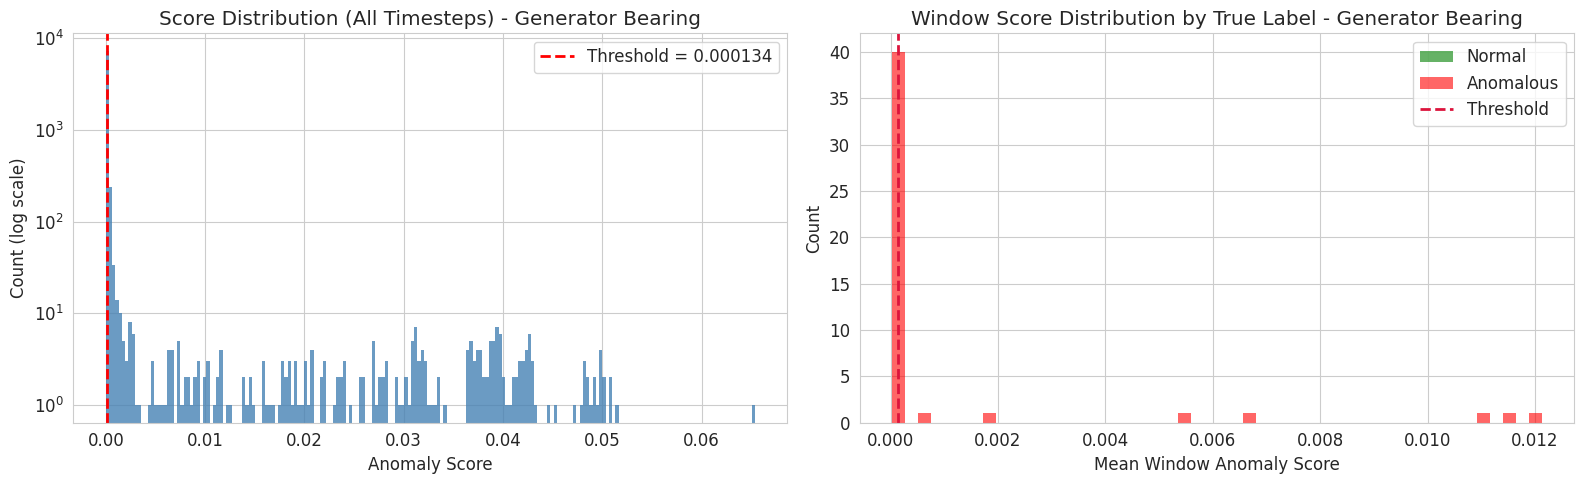

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution of all timestep-level scores (log scale)
ax1 = axes[0]
ax1.hist(flat_scores, bins=200, color='steelblue', alpha=0.8, edgecolor='none')
ax1.axvline(x=thresh, color='red', linestyle='--', linewidth=2, label=f'Threshold = {thresh:.6f}')
ax1.set_yscale('log')
ax1.set_xlabel('Anomaly Score')
ax1.set_ylabel('Count (log scale)')
ax1.set_title(f'Score Distribution (All Timesteps) - {MODEL_CLASSES[MODEL_]}')
ax1.legend()

# Distribution of window-level mean scores
ax2 = axes[1]
normal_wmean = window_mean_scores[np.array(all_true_labels) == 0]
anom_wmean = window_mean_scores[np.array(all_true_labels) == 1]

if len(normal_wmean) > 0:
    ax2.hist(normal_wmean, bins=50, color='green', alpha=0.6, label='Normal', edgecolor='none')
if len(anom_wmean) > 0:
    ax2.hist(anom_wmean, bins=50, color='red', alpha=0.6, label='Anomalous', edgecolor='none')
ax2.axvline(x=thresh, color='crimson', linestyle='--', linewidth=2, label='Threshold')
ax2.set_xlabel('Mean Window Anomaly Score')
ax2.set_ylabel('Count')
ax2.set_title(f'Window Score Distribution by True Label - {MODEL_CLASSES[MODEL_]}')
ax2.legend()

plt.tight_layout()
plt.show()

/home/rdb/Documents/nirban_documents/python_programs/.venv/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


test: torch.Size([7777, 82])
✓ Generator Bearing done
test: torch.Size([3286, 82])


/home/rdb/Documents/nirban_documents/python_programs/.venv/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


✓ Gearbox done
test: torch.Size([2295, 82])


/home/rdb/Documents/nirban_documents/python_programs/.venv/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


✓ Transformer done
test: torch.Size([2877, 82])


/home/rdb/Documents/nirban_documents/python_programs/.venv/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


✓ Hydraulic done

  WIND TURBINE ANOMALY DETECTION - ALL FAULT TYPES
       Fault Type  Accuracy  Precision   Recall       F1  Total Windows  True Faults  Detected Faults
Generator Bearing  0.796296   0.860000 0.914894 0.886598             54           47               50
          Gearbox  0.772727   1.000000 0.736842 0.848485             22           19               14
      Transformer  0.933333   0.933333 1.000000 0.965517             15           14               15
        Hydraulic  0.789474   0.812500 0.928571 0.866667             19           14               16


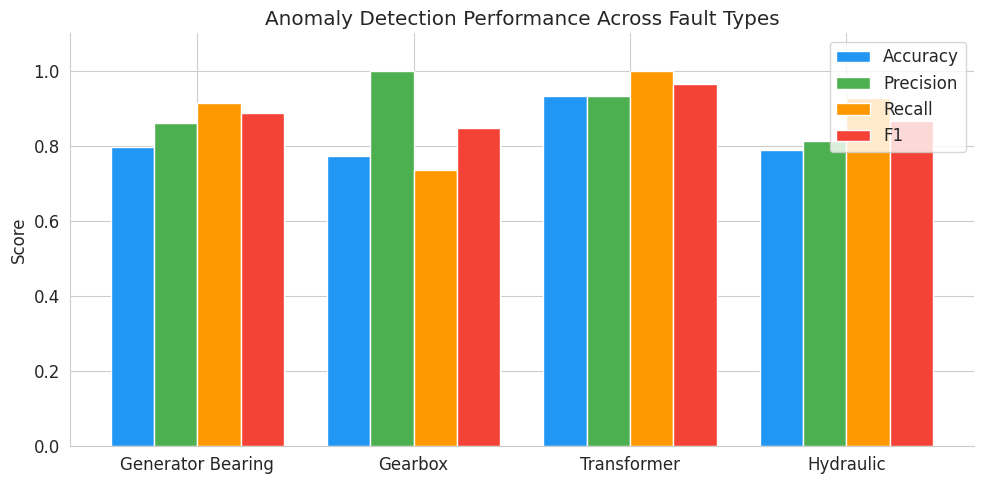

In [22]:
# Run across all 4 fault types and summarize
results_summary = []

for m_class in ['0', '1', '2', '3']:
    m_name = DATASET_NAME + m_class
    
    try:
        scaler_pth = OUTPUT_DIR / f"model_{m_class}" / "scaler.joblib"
        ckpt_pth = SAVE_MODEL_DIR / f"{DATASET_NAME}{m_class}_checkpoint1_.pth"
        
        if not ckpt_pth.exists():
            print(f"Checkpoint not found for class {m_class}, skipping.")
            continue
        
        sc = joblib.load(scaler_pth)
        tl, feats, _, _ = get_turbine_data_loader(
            str(DATA_DIR_TEST), m_name,
            batch_size=BATCH_SIZE, win_size=WIN_SIZE, step=STEP,
            mode='test', scaler=sc
        )
        
        mdl = AnomalyTransformer(win_size=WIN_SIZE, enc_in=INPUT_C, c_out=OUTPUT_C, e_layers=E_LAYERS)
        mdl.load_state_dict(torch.load(ckpt_pth, map_location=device), strict=False)
        mdl.to(device)
        mdl.eval()
        
        th = THRESH_MAP[m_class]
        crit = torch.nn.MSELoss(reduction='none')
        t_labels, p_labels = [], []
        
        with torch.no_grad():
            for inp_data, lbls, _ in tl:
                inp = inp_data.float().to(device)
                out, ser, pri, _ = mdl(inp)
                loss = torch.mean(crit(inp, out), dim=-1)
                s_loss, p_loss = 0.0, 0.0
                for u in range(len(pri)):
                    norm_prior = pri[u] / torch.unsqueeze(torch.sum(pri[u], dim=-1), dim=-1).repeat(1,1,1,WIN_SIZE)
                    if u == 0:
                        s_loss = my_kl_loss(ser[u], norm_prior.detach()) * TEMPERATURE
                        p_loss = my_kl_loss(norm_prior, ser[u].detach()) * TEMPERATURE
                    else:
                        s_loss += my_kl_loss(ser[u], norm_prior.detach()) * TEMPERATURE
                        p_loss += my_kl_loss(norm_prior, ser[u].detach()) * TEMPERATURE
                
                met = torch.softmax((-s_loss - p_loss), dim=-1)
                cr = (met * loss).detach().cpu().numpy()
                
                t_batch = lbls.view(-1).cpu().numpy().astype(int).tolist()
                p_batch = [
                    int(np.sum(cr[b] > th) >= np.round(ANORMLY_RATIO * cr[b].shape[0] / 100))
                    for b in range(cr.shape[0])
                ]
                t_labels.extend(t_batch)
                p_labels.extend(p_batch)
        
        results_summary.append({
            'Fault Type': MODEL_CLASSES[m_class],
            'Accuracy': accuracy_score(t_labels, p_labels),
            'Precision': precision_score(t_labels, p_labels, zero_division=0),
            'Recall': recall_score(t_labels, p_labels, zero_division=0),
            'F1': f1_score(t_labels, p_labels, zero_division=0),
            'Total Windows': len(t_labels),
            'True Faults': sum(t_labels),
            'Detected Faults': sum(p_labels)
        })
        print(f"✓ {MODEL_CLASSES[m_class]} done")
        
    except Exception as e:
        print(f"✗ {MODEL_CLASSES[m_class]} failed: {e}")

if results_summary:
    df_results = pd.DataFrame(results_summary)
    print("\n" + "=" * 80)
    print("  WIND TURBINE ANOMALY DETECTION - ALL FAULT TYPES")
    print("=" * 80)
    print(df_results.to_string(index=False))
    
    # Bar chart comparison
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(df_results))
    width = 0.2
    ax.bar(x - 1.5*width, df_results['Accuracy'], width, label='Accuracy', color='#2196F3')
    ax.bar(x - 0.5*width, df_results['Precision'], width, label='Precision', color='#4CAF50')
    ax.bar(x + 0.5*width, df_results['Recall'], width, label='Recall', color='#FF9800')
    ax.bar(x + 1.5*width, df_results['F1'], width, label='F1', color='#F44336')
    ax.set_xticks(x)
    ax.set_xticklabels(df_results['Fault Type'])
    ax.set_ylabel('Score')
    ax.set_title('Anomaly Detection Performance Across Fault Types')
    ax.legend()
    ax.set_ylim(0, 1.1)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    plt.tight_layout()
    plt.show()